In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from keras.models import Model
from keras.layers import Flatten,Dense
from keras.applications.vgg16 import VGG16
import matplotlib.pyplot as plot
from glob import glob

In [3]:
IMAGESHAPE = [224, 224, 3]
training_data = 'pneumonia_dataset/train'
testing_data = 'pneumonia_dataset/test'


Class: NORMAL


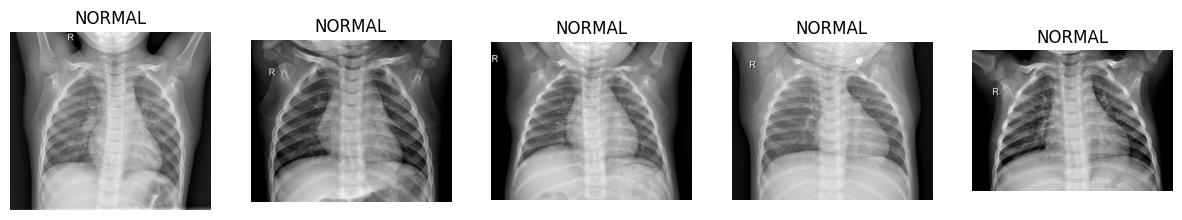


Class: PNEUMONIA


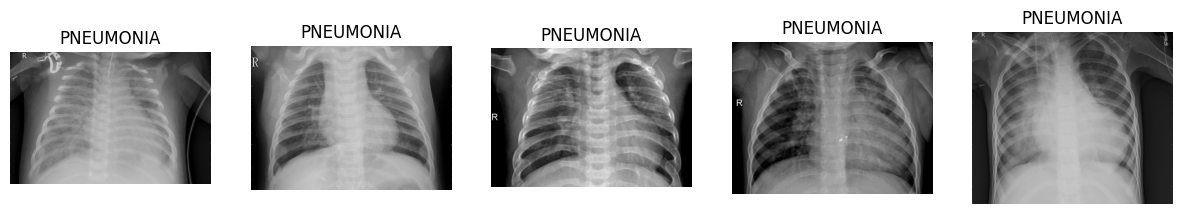

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import glob

base_path = "pneumonia_dataset/train"

# Loop through each class folder
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        print(f"\nClass: {class_name}")
        
        # Get first 5 image paths
        image_files = glob.glob(os.path.join(class_path, "*"))[:5]
        
        # Plot them
        plt.figure(figsize=(15, 5))
        for i, img_path in enumerate(image_files):
            img = mpimg.imread(img_path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img, cmap='gray')  # cmap='gray' for X-rays
            plt.axis('off')
            plt.title(class_name)
        plt.show()


Class: NORMAL


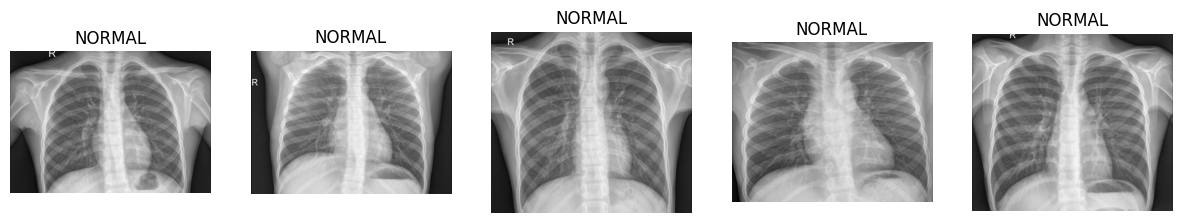


Class: PNEUMONIA


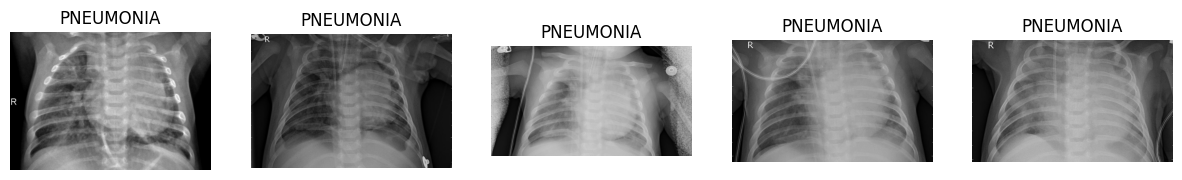

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import glob

base_path = "pneumonia_dataset/test"

# Loop through each class folder
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        print(f"\nClass: {class_name}")
        
        # Get first 5 image paths
        image_files = glob.glob(os.path.join(class_path, "*"))[:5]
        
        # Plot them
        plt.figure(figsize=(15, 5))
        for i, img_path in enumerate(image_files):
            img = mpimg.imread(img_path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img, cmap='gray')  # cmap='gray' for X-rays
            plt.axis('off')
            plt.title(class_name)
        plt.show()

In [7]:
import os
import glob

base_path = "pneumonia_dataset/train" 

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        # Count all files with common image extensions
        count = len(glob.glob(os.path.join(class_path, "*.jpg"))) \
              + len(glob.glob(os.path.join(class_path, "*.jpeg"))) \
              + len(glob.glob(os.path.join(class_path, "*.png")))
        print(f"{class_name}: {count} images")

NORMAL: 1341 images
PNEUMONIA: 3875 images


In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    "pneumonia_dataset/train",
    target_size=(224, 224),
    batch_size=4,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extract class labels and sample distribution from the generator
class_labels = list(train_generator.class_indices.keys())
class_indices = train_generator.class_indices
classes_array = train_generator.classes  # array of 0s and 1s

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes_array),
    y=classes_array
)

# Map weights to class indices
class_weights = dict(zip(np.unique(classes_array), class_weights_array))

print("Class labels:", class_labels)
print("Class weights:", class_weights)

Class labels: ['NORMAL', 'PNEUMONIA']
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [39]:
vgg_model = VGG16(input_shape=(224, 224, 3), weights='imagenet', include_top=False)

In [40]:
for each_layer in vgg_model.layers:
	each_layer.trainable = False

In [41]:
import glob

classes = glob.glob("pneumonia_dataset/train/*")
print(classes)

['pneumonia_dataset/train\\NORMAL', 'pneumonia_dataset/train\\PNEUMONIA']


In [42]:
x = GlobalAveragePooling2D()(vgg_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
prediction = Dense(1, activation='sigmoid')(x)

In [43]:
model = Model(inputs=vgg_model.input, outputs=prediction)

In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "pneumonia_dataset/test",
    target_size=(224, 224),
    batch_size=4,
    class_mode='binary',
    shuffle=False
)

Found 625 images belonging to 2 classes.


In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_vgg16.h5', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
1304/1304 [==============================] - 204s 153ms/step - loss: 0.3427 - accuracy: 0.8516 - val_loss: 0.3184 - val_accuracy: 0.8624 - lr: 0.0010
Epoch 2/20
1304/1304 [==============================] - 207s 159ms/step - loss: 0.2328 - accuracy: 0.9041 - val_loss: 0.2860 - val_accuracy: 0.8848 - lr: 0.0010
Epoch 3/20
1304/1304 [==============================] - 194s 148ms/step - loss: 0.2167 - accuracy: 0.9143 - val_loss: 0.3167 - val_accuracy: 0.8784 - lr: 0.0010
Epoch 4/20
1304/1304 [==============================] - 204s 156ms/step - loss: 0.2134 - accuracy: 0.9153 - val_loss: 0.2738 - val_accuracy: 0.8928 - lr: 0.0010
Epoch 5/20
1304/1304 [==============================] - 189s 145ms/step - loss: 0.1921 - accuracy: 0.9262 - val_loss: 0.2756 - val_accuracy: 0.8800 - lr: 0.0010
Epoch 6/20
1304/1304 [==============================] - 204s 156ms/step - loss: 0.1870 - accuracy: 0.9296 - val_loss: 0.2988 - val_accuracy: 0.8720 - lr: 0.0010
Epoch 7/20
1304/1304 [============

157/157 [==============================] - 14s 88ms/step


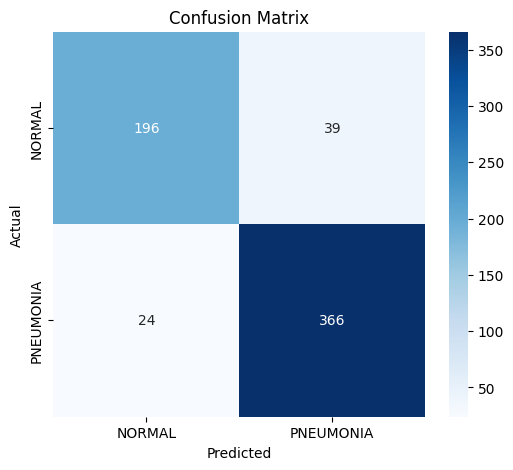


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.83      0.86       235
   PNEUMONIA       0.90      0.94      0.92       390

    accuracy                           0.90       625
   macro avg       0.90      0.89      0.89       625
weighted avg       0.90      0.90      0.90       625


ROC-AUC Score: 0.9516


In [53]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Get predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# Step 2: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 3: Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# Step 4: ROC-AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

In [60]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "pneumonia_dataset/val/NORMAL/NORMAL2-IM-1431-0001.jpeg"  # replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

prediction_prob = model.predict(img_array)[0][0]
prediction_class = "PNEUMONIA" if prediction_prob > 0.6 else "NORMAL"

print(f"Prediction: {prediction_class}")
print(f"Score: {prediction_prob:.4f}")


1/1 [==============================] - 0s 76ms/step
Prediction: NORMAL
Score: 0.5522


In [61]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "pneumonia_dataset/val/PNEUMONIA/person1946_bacteria_4875.jpeg"  # replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

prediction_prob = model.predict(img_array)[0][0]
prediction_class = "PNEUMONIA" if prediction_prob > 0.6 else "NORMAL"

print(f"Prediction: {prediction_class}")
print(f"Score: {prediction_prob:.4f}")


1/1 [==============================] - 0s 50ms/step
Prediction: PNEUMONIA
Score: 0.9884


In [62]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "pneumonia_dataset/val/NORMAL/NORMAL2-IM-1442-0001.jpeg"  # replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

prediction_prob = model.predict(img_array)[0][0]
prediction_class = "PNEUMONIA" if prediction_prob > 0.6 else "NORMAL"

print(f"Prediction: {prediction_class}")
print(f"Score: {prediction_prob:.4f}")


1/1 [==============================] - 0s 46ms/step
Prediction: NORMAL
Score: 0.0301


In [64]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "pneumonia_dataset/val/NORMAL/NORMAL2-IM-1438-0001.jpeg"  # replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

prediction_prob = model.predict(img_array)[0][0]
prediction_class = "PNEUMONIA" if prediction_prob > 0.6 else "NORMAL"

print(f"Prediction: {prediction_class}")
print(f"Score: {prediction_prob:.4f}")


1/1 [==============================] - 0s 45ms/step
Prediction: NORMAL
Score: 0.4583


In [65]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "1000_F_178658719_KqnoFz4uYDSJCC5kQA682M5zqKE70eLB.jpg"  # replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

prediction_prob = model.predict(img_array)[0][0]
prediction_class = "PNEUMONIA" if prediction_prob > 0.6 else "NORMAL"

print(f"Prediction: {prediction_class}")
print(f"Score: {prediction_prob:.4f}")


1/1 [==============================] - 0s 55ms/step
Prediction: PNEUMONIA
Score: 0.7818


In [66]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "Screenshot 2025-09-11 214712.png"  # replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # rescale
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

prediction_prob = model.predict(img_array)[0][0]
prediction_class = "PNEUMONIA" if prediction_prob > 0.6 else "NORMAL"

print(f"Prediction: {prediction_class}")
print(f"Score: {prediction_prob:.4f}")


1/1 [==============================] - 0s 53ms/step
Prediction: PNEUMONIA
Score: 0.7837
